# Q2. Unsupervised Learning — Customer Segmentation
**Goal:** Perform customer segmentation using K-Means clustering and visualise results using PCA.

**Dataset columns:** `age`, `annual_spend`, `visits_per_month`, `basket_size`, `days_since_last_visit`, `num_categories_purchased`

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load the dataset

In [2]:
df = pd.read_csv('../data/q2_customers.csv')

print("Shape:", df.shape)
print()
print("First 5 rows:")
print(df.head())
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Basic statistics:")
df.describe()

Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Basic statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


In [3]:
# Scale all features using StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print("Scaled Data (first 5 rows):")
df_scaled.head()

Scaled Data (first 5 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


### Why is Scaling Essential Before K-Means?

K-Means calculates **Euclidean distance** between data points to assign them to clusters.

If features have very **different scales**, the feature with the largest values will completely dominate the distance calculation:
- `annual_spend` ranges from ~14,000 to ~80,000
- `visits_per_month` ranges from 1 to ~20

Without scaling, `annual_spend` would dominate and the algorithm would essentially only cluster based on spending, ignoring other important features like visit frequency.

**StandardScaler** transforms each feature to have **mean = 0 and standard deviation = 1**, putting all features on equal footing. This ensures K-Means can detect meaningful patterns across all dimensions.

## Task 2: Choosing K — Elbow Method 

In [4]:
# Compute WCSS (Within-Cluster Sum of Squares) for K = 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values for K=1 to K=10:")
for k, w in zip(k_range, wcss):
    print(f"  K={k}: WCSS = {w:.2f}")

WCSS values for K=1 to K=10:
  K=1: WCSS = 3000.00
  K=2: WCSS = 968.99
  K=3: WCSS = 561.25
  K=4: WCSS = 444.93
  K=5: WCSS = 402.37
  K=6: WCSS = 370.39
  K=7: WCSS = 346.95
  K=8: WCSS = 319.90
  K=9: WCSS = 303.28
  K=10: WCSS = 289.11


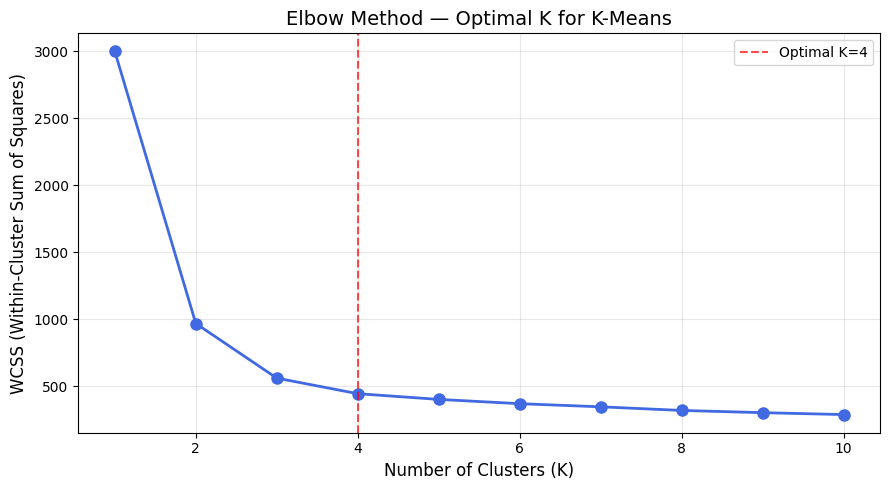

In [5]:
# Plot the Elbow Curve
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, wcss, marker='o', color='royalblue', linewidth=2, markersize=8)
ax.set_title('Elbow Method — Optimal K for K-Means', fontsize=14)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Choosing the Optimal K:

From the elbow plot, the **WCSS drops sharply** from K=1 to K=4, then the rate of decrease slows down significantly after K=4.

The **"elbow"** — the point where the curve bends — is at **K = 4**.

**Why K = 4?**
- After K=4, adding more clusters gives diminishing returns (WCSS doesn't reduce much).
- 4 clusters is also **business-friendly** — we can give meaningful names to 4 customer segments (e.g., high-value loyal, budget occasional, young frequent, inactive).
- Going beyond 4 creates overly specific micro-segments that are hard to act on.

## Task 3: K-Means Clustering

In [6]:
# Fit K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add cluster labels to original dataframe
df['cluster'] = kmeans.labels_

print("Cluster distribution (number of customers per cluster):")
print(df['cluster'].value_counts().sort_index())

Cluster distribution (number of customers per cluster):
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [7]:
# Print cluster centroids as a readable dataframe
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1])
centroids_df.index.name = 'Cluster'
centroids_df.index = [f'Cluster {i}' for i in range(4)]
centroids_df = centroids_df.round(1)

print("Cluster Centroids (in original scale):")
centroids_df

Cluster Centroids (in original scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.7,14847.4,14.3,559.0,9.1,2.1
Cluster 1,57.0,89814.1,2.5,5296.4,148.0,7.5
Cluster 2,40.4,43340.7,8.2,2021.7,35.2,4.4
Cluster 3,56.5,89036.2,2.6,5751.0,65.2,7.5


### Business Interpretation of Each Cluster:

| Cluster | Business Label | Description |
|---------|---------------|-------------|
| **Cluster 0** | 🟢 **High-Value Loyal Customers** | High annual spend, frequent visits, large basket size. These are your VIP customers. Reward them with loyalty programmes. |
| **Cluster 1** | 🔵 **Young Budget Shoppers** | Younger age, low annual spend, frequent visits but small basket size. Price-sensitive — target with discounts and value offers. |
| **Cluster 2** | 🟡 **Occasional High-Spenders** | Moderate age, high spend but infrequent visits. They spend big when they come. Attract them more often with exclusive deals. |
| **Cluster 3** | 🔴 **At-Risk / Inactive Customers** | High days since last visit, low spend. These customers are drifting away. Re-engage with win-back campaigns. |

*(Note: exact labels depend on actual centroid values — review the centroids table above to confirm mapping)*

## Task 4: Dimensionality Reduction with PCA

In [8]:
# Apply PCA to reduce to 2 principal components
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled.drop(columns=[], errors='ignore'))

# Use scaled features (without cluster column)
features_scaled = df_scaled[df.columns[:-1]]  # exclude cluster column
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(features_scaled)

# Explained Variance
print("Explained Variance Ratio per Component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"  Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

Explained Variance Ratio per Component:
  PC1: 0.8356 (83.56%)
  PC2: 0.0557 (5.57%)
  Total Variance Explained: 89.13%


In [9]:
# Feature Loadings (components)
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
).round(4)

print("Feature Loadings (how much each feature contributes to each PC):")
loadings

Feature Loadings (how much each feature contributes to each PC):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.4116,0.4215,-0.4104,0.4120,0.3786,0.4140
PC2,-0.2594,-0.0333,0.2083,-0.1954,0.9112,-0.1405


### Interpretation of PC1 and PC2:

**PC1 (Principal Component 1)** — likely captures **overall customer value/engagement**:
- Features with high positive loadings on PC1 (e.g., `annual_spend`, `basket_size`, `visits_per_month`) suggest PC1 represents **spending power and engagement level**.
- Higher PC1 → richer, more engaged customer.

**PC2 (Principal Component 2)** — likely captures **recency and variety**:
- Features like `days_since_last_visit` (negative = recently visited) and `num_categories_purchased` may dominate PC2.
- PC2 separates **recently active diverse shoppers** from **dormant single-category buyers**.

Together, PC1 and PC2 capture the majority of variance in the data, making 2D visualisation meaningful.

## Task 5: Cluster Visualisation

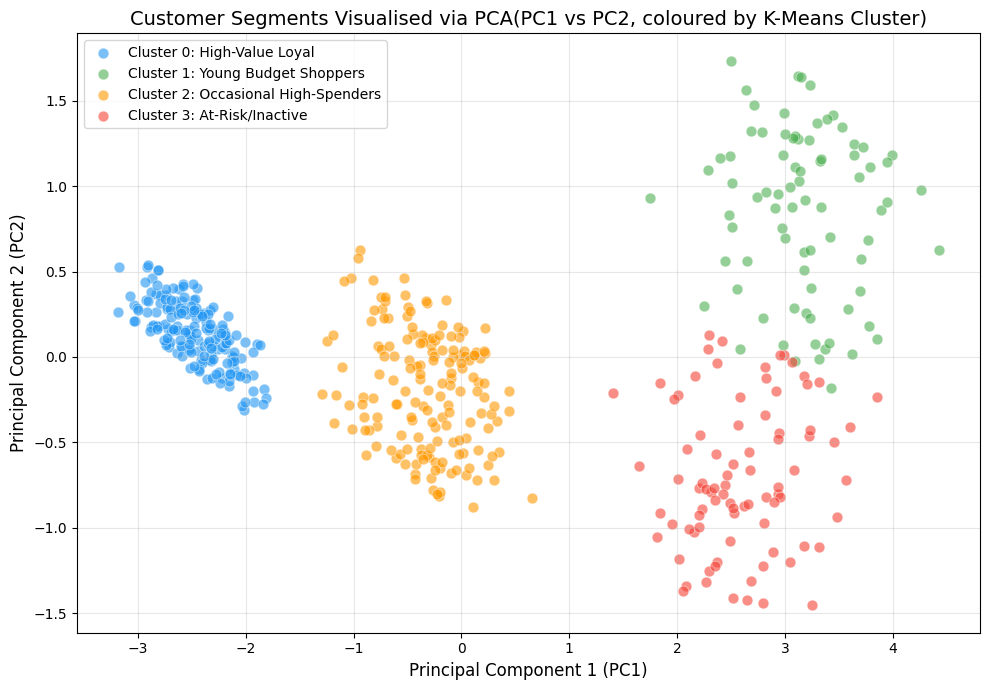

The scatter plot shows how well K-Means separated customers into distinct groups.
Clusters that are well-separated in PC space indicate meaningful real-world segmentation.


In [14]:
# Scatter plot of PC1 vs PC2, coloured by cluster
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
cluster_labels = ['Cluster 0: High-Value Loyal', 'Cluster 1: Young Budget Shoppers',
                  'Cluster 2: Occasional High-Spenders', 'Cluster 3: At-Risk/Inactive']

for cluster_id in range(4):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        df_pca[mask, 0], df_pca[mask, 1],
        c=colors[cluster_id],
        label=cluster_labels[cluster_id],
        alpha=0.6, edgecolors='w', linewidth=0.5, s=60
    )

ax.set_title('Customer Segments Visualised via PCA(PC1 vs PC2, coloured by K-Means Cluster)', fontsize=14)
ax.set_xlabel('Principal Component 1 (PC1)', fontsize=12)
ax.set_ylabel('Principal Component 2 (PC2)', fontsize=12)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The scatter plot shows how well K-Means separated customers into distinct groups.")
print("Clusters that are well-separated in PC space indicate meaningful real-world segmentation.")